# 05 - Utility Scoring V2

**Goal**: Implement a new, self-contained utility scoring system for the Artemis VLM Router.

**Stages**:
1. **Stage 1**: Define and compute `utility_accuracy` (combining static metrics, Glider, and Judge).
2. **Stage 2**: Define and compute `utility_cheap`, `utility_fast`, `utility_balanced` (resource-aware utilities).

**Output**: Updates `vlm_responses` table with new utility columns (accuracy + resource-aware views).

**Data flow**:
1. Query `vlm_responses` joined to `vlm_evaluations` so we only score samples that passed initial filtering.
2. Stage 1 collapses the static, Glider, Judge, and semantic signals into `utility_accuracy`.
3. Stage 2 normalizes cost/latency and derives resource-sensitive utilities before writing everything back.

**Persistence**: Prior to calculations we migrate schema (if needed) and the final stage uses a temp table to bulk-update `vlm_responses`, making the notebook idempotent.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# === Path Setup ===
import sys
from pathlib import Path

# Notebook paths
NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent
ROOT_DIR = ARTEMIS_DIR.parent

# Add to sys.path
for p in [str(ARTEMIS_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f" ARTEMIS_DIR: {ARTEMIS_DIR}")

# Imports
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import logging
from sqlalchemy import text
from ares.db.connection import get_engine

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(name)-15s | %(message)s', datefmt='%H:%M:%S')

📁 ARTEMIS_DIR: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# === Database Connection ===
engine = get_engine()
print("Connected to DB")

# Ensure new columns exist (Migration step)
with engine.connect() as conn:
    # Stage 1 Column
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS utility_accuracy FLOAT"))
    
    # Stage 2 Columns
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS cost_norm_new FLOAT"))
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS lat_norm FLOAT"))
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS utility_cheap FLOAT"))
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS utility_fast FLOAT"))
    conn.execute(text("ALTER TABLE vlm_responses ADD COLUMN IF NOT EXISTS utility_balanced FLOAT"))
    conn.commit()

print("Schema checked/migrated.")

Connected to DB
Schema checked/migrated.


## Stage 1: Compute `utility_accuracy`

This stage merges static correctness, Glider, Judge, and semantic signals into a single accuracy score. We only operate on rows whose original response was marked `ok = true`, and we keep the normalized signals in `df` for reuse.

### Normalized signals
- `gt_norm`: prefer `score_exact_match_normalized`, fallback to `score_numeric_match`, `score_mc_letter_match`, and finally `is_correct` so the signal stays in [0, 1].
- `glider_norm`: rescales `glider_score / 5` when Glider feedback exists.
- `judge_norm`: clamps `judge_molmo_score` into [0, 10] before dividing by 10 so judge opinions map to [0, 1].
- `semantic_norm`: directly uses `semantic_f1_f1` as-is, under the assumption that it already lies in [0, 1].
- `rank_norm`: for each `sample_id`, we turn 1-based `judge_molmo_rank_group` into a [0, 1] score via \(1 - \frac{rank - 1}{max\_rank - 1}\); rankings that are missing stay `null`.

### Aggregation strategy
Every row picks a weight template depending on the best available signals:
- Judge present: `gt` weights 0.3, `judge` 0.4, `rank` 0.2, `glider` 0.05, `semantic` 0.05.
- Judge missing but Glider/Semantic present: rely on `gt` 0.4, `glider` 0.3, `semantic` 0.3 and ignore judge/rank.
- Only static GT: fall back to `gt` weight 1.0.
We then drop absent signals, renormalize the remaining weights, and compute:
\[
utility\_accuracy = \frac{\sum\_{s} w\_s \cdot signal\_s}{\sum\_{s} w\_s}
\]
If somehow no signal is available, we default to 0, but that should only happen on very dirty data.


In [4]:
# === Load raw responses + metadata for utility scoring ===

query = """
SELECT
    r.response_id,
    r.sample_id,
    s.router_task,
    s.data_split,
    s.source_dataset,
    s.txt_prompt_length_words,
    s.prompt_text,
    r.model_name,
    r.latency_ms,
    r.is_correct,
    r.estimated_cost_usd,
    r.score_exact_match_normalized,
    r.score_numeric_match,
    r.score_mc_letter_match,
    e.glider_score,
    e.semantic_f1_f1,
    e.judge_molmo_score,
    e.judge_molmo_rank_group
FROM vlm_responses r
JOIN vlm_samples s
    ON r.sample_id = s.sample_id
LEFT JOIN vlm_evaluations e
    ON e.sample_id = r.sample_id
   AND e.model_name = r.model_name
WHERE r.ok = TRUE
  AND s.router_task IS NOT NULL
  AND r.model_name IS NOT NULL
"""

print("Loading data for utility scoring...")
df = pd.read_sql(query, engine)
print(f"Loaded {len(df)} rows.")
display(df.head())


Loading data for utility scoring...
Loaded 339056 rows.


,response_id,sample_id,router_task,data_split,source_dataset,txt_prompt_length_words,prompt_text,model_name,latency_ms,is_correct,estimated_cost_usd,score_exact_match_normalized,score_numeric_match,score_mc_letter_match,glider_score,semantic_f1_f1,judge_molmo_score,judge_molmo_rank_group
0,32228,aokvqa_796_8644de03,knowledge_vqa,test,cauldron,29,How many women are holding umbrellas in front ...,qwen2_5_vl_7b,3195.0,True,0.000099,0.0,NaN,NaN,5.0,None,NaN,NaN
1,29988,figureqa_98_0b67ef87,chart_reasoning,test,cauldron,8,Is Slate the minimum?\nAnswer yes or no.,qwen2_5_vl_7b,305.0,True,0.000063,1.0,NaN,NaN,5.0,None,10.0,1.0
2,33213,docvqa_221_ac3aa612,document_ocr,train,cauldron,13,What is the Urgent/Immediate Action Commercial...,qwen2_5_vl_7b,2342.0,True,0.000775,1.0,NaN,NaN,5.0,None,10.0,1.0
3,31983,figureqa_189_e1ecd121,chart_reasoning,train,cauldron,9,Is Dark Gray the minimum?\nAnswer yes or no.,qwen2_5_vl_7b,261.0,True,0.000066,1.0,NaN,NaN,5.0,None,NaN,NaN
4,34833,docvqa_270_ca57d063,document_ocr,train,cauldron,12,What is the title of the document?\nEnsure bre...,qwen2_5_vl_7b,2398.0,True,0.000975,0.0,NaN,NaN,5.0,None,10.0,1.0


In [5]:
# === Compute Normalized Signals ===

import numpy as np

# ---- Ground truth–style accuracy in [0, 1] ----
def compute_gt_norm(row):
    """
    Priority:
    1) score_exact_match_normalized (already 0-1)
    2) score_numeric_match          (0-1)
    3) score_mc_letter_match        (0-1)
    4) Fallback: is_correct ∈ {0,1}
    """
    if pd.notnull(row.get("score_exact_match_normalized")):
        return float(row["score_exact_match_normalized"])
    
    if pd.notnull(row.get("score_numeric_match")):
        return float(row["score_numeric_match"])
    
    if pd.notnull(row.get("score_mc_letter_match")):
        return float(row["score_mc_letter_match"])
    
    # Fallback to simple correctness
    if "is_correct" in row and pd.notnull(row["is_correct"]):
        return 1.0 if bool(row["is_correct"]) else 0.0
    
    return np.nan

df["gt_norm"] = df.apply(compute_gt_norm, axis=1)

# ---- Judge signal in [0, 1] ----
def compute_judge_norm(x):
    """
    Judge scores are usually on [0, 10] (or similar).
    We clamp to [0, 10] and divide by 10 for stability.
    """
    if pd.isnull(x):
        return np.nan
    v = float(x)
    v = max(0.0, min(v, 10.0))
    return v / 10.0

df["judge_norm"] = df["judge_molmo_score"].apply(compute_judge_norm)

# ---- Semantic F1 in [0, 1] ----
def compute_semantic_norm(x):
    if pd.isnull(x):
        return np.nan
    v = float(x)
    # Most F1-like scores are already 0-1; just clamp.
    return max(0.0, min(v, 1.0))

df["semantic_norm"] = df["semantic_f1_f1"].apply(compute_semantic_norm)

# ---- Glider score in [0, 1] ----
def compute_glider_norm(x):
    """
    If glider_score is roughly in [-5, 5], we clamp to that range
    and linearly map to [0, 1].
    Adjust if you know the concrete glider scale, but this
    is stable and monotonic as a default.
    """
    if pd.isnull(x):
        return np.nan
    v = float(x)
    v = max(-5.0, min(v, 5.0))
    return (v + 5.0) / 10.0

df["glider_norm"] = df["glider_score"].apply(compute_glider_norm)

# ---- Rank signal in [0, 1] (optional, NOT used in utility_accuracy) ----
def compute_rank_norm_per_group(group: pd.DataFrame) -> pd.Series:
    """
    Convert judge_molmo_rank_group into [0, 1] within each sample_id:
      best rank (1) -> 1.0
      worst rank    -> 0.0
    """
    ranks = group["judge_molmo_rank_group"]
    if ranks.notnull().sum() == 0:
        return pd.Series([np.nan] * len(group), index=group.index)
    
    max_rank = float(ranks.max())
    if max_rank == 1.0:
        # Only one ranked candidate: give full score
        return ranks.apply(lambda r: 1.0 if pd.notnull(r) else np.nan)
    
    def rank_to_score(r):
        if pd.isnull(r):
            return np.nan
        r = float(r)
        return 1.0 - (r - 1.0) / (max_rank - 1.0)

    return ranks.apply(rank_to_score)

df["rank_norm"] = (
    df.groupby("sample_id", group_keys=False)
      .apply(compute_rank_norm_per_group)
)

print("Signals computed: gt_norm, judge_norm, semantic_norm, glider_norm, rank_norm")
display(
    df[["gt_norm", "judge_norm", "semantic_norm", "glider_norm", "rank_norm"]].head()
)

Signals computed: gt_norm, judge_norm, semantic_norm, glider_norm, rank_norm


/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_96944/2035815157.py:97: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_rank_norm_per_group)


,gt_norm,judge_norm,semantic_norm,glider_norm,rank_norm
0,0.0,NaN,NaN,1.0,NaN
1,1.0,1.0,NaN,1.0,1.0
2,1.0,1.0,NaN,1.0,1.0
3,1.0,NaN,NaN,1.0,NaN
4,0.0,1.0,NaN,1.0,1.0


In [6]:
# === Compute Utility Accuracy ===

def compute_utility_accuracy(row):
    """
    Clean, ordered fallback:

    1) Ground-truth style metrics (gt_norm),
    2) Judge score,
    3) Semantic F1,
    4) Glider,
    5) Fallback 0.0.

    We DO NOT mix these with weights anymore: this keeps the
    supervision consistent and easy for the router to learn.
    """
    if pd.notnull(row.get("gt_norm")):
        return float(row["gt_norm"])
    
    if pd.notnull(row.get("judge_norm")):
        return float(row["judge_norm"])
    
    if pd.notnull(row.get("semantic_norm")):
        return float(row["semantic_norm"])
    
    if pd.notnull(row.get("glider_norm")):
        return float(row["glider_norm"])
    
    # Last resort
    return 0.0

df["utility_accuracy"] = df.apply(compute_utility_accuracy, axis=1)

print("Utility Accuracy Distribution:")
print(df["utility_accuracy"].describe())
display(df[["utility_accuracy", "gt_norm", "judge_norm", "semantic_norm", "glider_norm"]].head())


Utility Accuracy Distribution:
count    339056.000000
mean          0.123549
std           0.329067
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: utility_accuracy, dtype: float64


,utility_accuracy,gt_norm,judge_norm,semantic_norm,glider_norm
0,0.0,0.0,NaN,NaN,1.0
1,1.0,1.0,1.0,NaN,1.0
2,1.0,1.0,1.0,NaN,1.0
3,1.0,1.0,NaN,NaN,1.0
4,0.0,0.0,1.0,NaN,1.0


## Stage 2: Resource-Aware Utilities

After `utility_accuracy` is stable, we layer in resource signals so downstream selection can trade off cost and latency.

### Normalized cost and latency
- `cost_norm_new`: min-max normalization of `estimated_cost_usd`, mapping the cheapest response to 0 and the most expensive to 1.
- `lat_norm`: the same min-max transform on `latency_ms`, with missing or constant data collapsed to 0.

### Derived utilities
- `utility_cheap`: zero unless `utility_accuracy >= 0.3`; otherwise it is \(0.6 \cdot utility\_accuracy + 0.4 \cdot (1 - cost\_norm\_new)\).
- `utility_fast`: zero unless `utility_accuracy >= 0.3`; if `lat_norm` is null the row is marked 0 because we cannot prove slowness; otherwise it mixes \(0.6 \cdot utility\_accuracy + 0.4 \cdot (1 - lat\_norm)\).
- `utility_balanced`: always defined and blends accuracy, cost, and latency as \(0.5 \cdot utility\_accuracy + 0.25 \cdot (1 - cost\_norm\_new) + 0.25 \cdot (1 - lat\_norm)\), treating missing latency as the worst case so the latency term contributes 0.
These resource utilities give cheap/fast/balanced signals that still honor our accuracy floor while punishing expensive or slow responses.


In [7]:
# === Normalize Costs and Latency ===

import numpy as np

# --- Cost Normalization [0, 1] ---
# Lower cost => smaller raw value, but we'll use (1 - cost_norm) for utilities.
min_cost = df["estimated_cost_usd"].min()
max_cost = df["estimated_cost_usd"].max()

if pd.notnull(max_cost) and pd.notnull(min_cost) and max_cost > min_cost:
    df["cost_norm_new"] = (df["estimated_cost_usd"] - min_cost) / (max_cost - min_cost)
else:
    df["cost_norm_new"] = 0.0  # degenerate case

# --- Latency Normalization [0, 1] ---
min_lat = df["latency_ms"].min()
max_lat = df["latency_ms"].max()

if pd.notnull(max_lat) and pd.notnull(min_lat) and max_lat > min_lat:
    df["lat_norm"] = (df["latency_ms"] - min_lat) / (max_lat - min_lat)
else:
    df["lat_norm"] = 0.0

# --- Mode-specific utilities ---
# Cheap: only cares about cost
def calc_cheap(row):
    if pd.isnull(row["cost_norm_new"]):
        return 0.0
    # Cheapest -> cost_norm_new ~ 0 -> utility_cheap ~ 1
    return 1.0 - float(row["cost_norm_new"])

# Fast: only cares about latency
def calc_fast(row):
    if pd.isnull(row["lat_norm"]):
        return 0.0
    # Fastest -> lat_norm ~ 0 -> utility_fast ~ 1
    return 1.0 - float(row["lat_norm"])

df["utility_cheap"] = df.apply(calc_cheap, axis=1)
df["utility_fast"] = df.apply(calc_fast, axis=1)

# Balanced: trade-off between accuracy and (cheap, fast)
def calc_balanced(row):
    acc = float(row["utility_accuracy"])
    cheap = float(row["utility_cheap"])
    fast = float(row["utility_fast"])
    # 0.5 accuracy, 0.25 cost, 0.25 latency
    return 0.5 * acc + 0.25 * cheap + 0.25 * fast

df["utility_balanced"] = df.apply(calc_balanced, axis=1)

print("Utilities Calculated.")
display(
    df[["model_name", "utility_accuracy", "utility_cheap", "utility_fast", "utility_balanced"]].head()
)


Utilities Calculated.


,model_name,utility_accuracy,utility_cheap,utility_fast,utility_balanced
0,qwen2_5_vl_7b,0.0,0.986553,0.968584,0.488784
1,qwen2_5_vl_7b,1.0,0.991472,0.997298,0.997192
2,qwen2_5_vl_7b,1.0,0.893615,0.977059,0.967668
3,qwen2_5_vl_7b,1.0,0.991059,0.997735,0.997199
4,qwen2_5_vl_7b,0.0,0.866107,0.976502,0.460652


## Stage 3: Persist Calculated Utilities

To keep the notebook idempotent we already ensured the columns exist and now bulk push the computed rows back to `vlm_responses`.
Using a temporary table (`temp_utility_updates`), we upload `response_id` plus the new metrics via `to_sql`, then run a single `UPDATE ... FROM` statement inside `engine.begin()` so the write is atomic. The temp table drops at the end of the session.


In [8]:
# === Write Back to Database ===

# Efficient bulk update using a temporary table pattern
# 1. Create temp table
# 2. Insert metrics
# 3. Update main table from temp

temp_table_name = "temp_utility_updates"

update_df = df[['response_id', 
                'utility_accuracy', 
                'cost_norm_new', 
                'lat_norm', 
                'utility_cheap', 
                'utility_fast', 
                'utility_balanced']].copy()

with engine.begin() as conn:
    # Ensure no leftover temp table
    conn.execute(text(f"DROP TABLE IF EXISTS {temp_table_name}"))
    # Create temp table
    conn.execute(text(f"""
        CREATE TEMP TABLE {temp_table_name} (
            response_id INTEGER PRIMARY KEY,
            utility_accuracy FLOAT,
            cost_norm_new FLOAT,
            lat_norm FLOAT,
            utility_cheap FLOAT,
            utility_fast FLOAT,
            utility_balanced FLOAT
        )
    """))
    
    # Upload data to temp table
    update_df.to_sql(temp_table_name, conn, if_exists='append', index=False)
    print(f"Uploaded {len(update_df)} rows to temp table")
    
    # Update main table
    update_query = text(f"""
        UPDATE vlm_responses AS r
        SET 
            utility_accuracy = t.utility_accuracy,
            cost_norm_new = t.cost_norm_new,
            lat_norm = t.lat_norm,
            utility_cheap = t.utility_cheap,
            utility_fast = t.utility_fast,
            utility_balanced = t.utility_balanced
        FROM {temp_table_name} AS t
        WHERE r.response_id = t.response_id
    """)
    
    result = conn.execute(update_query)
    print(f"Updated {result.rowcount} rows in vlm_responses")
    
    # Cleanup handled by auto-drop of temp table, but explicit drop involves transaction commit implicitly sometimes? 
    # Temp tables drop at end of session. Engine.begin() commits at exit.

print("Done.")

Uploaded 339056 rows to temp table
Updated 339056 rows in vlm_responses
Done.


In [15]:
# === Visualization: per-task, per-mode utilities ===

import matplotlib.pyplot as plt

# Make sure required columns exist
required_cols = [
    "router_task",
    "model_name",
    "utility_accuracy",
    "utility_cheap",
    "utility_fast",
    "utility_balanced",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns for plotting: {missing}")

# 1. Aggregate mean utilities per (task, model)
agg_cols = ["utility_accuracy", "utility_cheap", "utility_fast", "utility_balanced"]

avg_utils = (
    df.groupby(["router_task", "model_name"])[agg_cols]
      .mean()
      .reset_index()
)

print("Per-task, per-model average utilities:")
display(avg_utils.head())

# 2. Helper function: plot one task, all modes
def plot_task_mode_utilities(task_name: str, top_k: int = None):
    """
    For a given router_task, show bar plots of mean utility per model for:
      - accuracy
      - cheap
      - fast
      - balanced

    Args:
        task_name: name of router_task to plot.
        top_k: if set, only show top_k models (by accuracy utility) to keep plot readable.
    """
    task_df = avg_utils[avg_utils["router_task"] == task_name].copy()
    if task_df.empty:
        print(f"No data for task: {task_name}")
        return

    # Optionally, keep only top_k models by accuracy utility (for readability)
    task_df = task_df.sort_values("utility_accuracy", ascending=False)
    if top_k is not None and top_k > 0:
        task_df = task_df.head(top_k)

    models = task_df["model_name"].tolist()

    modes = [
        ("utility_accuracy", "Accuracy mode"),
        ("utility_cheap", "Cheap mode"),
        ("utility_fast", "Fast mode"),
        ("utility_balanced", "Balanced mode"),
    ]

    num_modes = len(modes)
    fig, axes = plt.subplots(1, num_modes, figsize=(4 * num_modes, 5), sharey=True)

    if num_modes == 1:
        axes = [axes]

    for ax, (col, title) in zip(axes, modes):
        values = task_df[col].tolist()
        ax.bar(range(len(models)), values)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=90)
        ax.set_title(title)
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel("Mean utility")
    
    fig.suptitle(f"Per-model utilities for task: {task_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# 3. Convenience: quickly list all tasks
all_tasks = sorted(avg_utils["router_task"].unique())
print("Available tasks:")
for t in all_tasks:
    print(" -", t)

Per-task, per-model average utilities:


,router_task,model_name,utility_accuracy,utility_cheap,utility_fast,utility_balanced
0,abstract_reasoning,deepseek_ocr,0.000,0.996940,0.992509,0.497362
1,abstract_reasoning,gemma_3_27b,0.073,0.993093,0.957706,0.524200
2,abstract_reasoning,qwen2_5_vl_3b,0.376,0.988296,0.986741,0.681759
3,abstract_reasoning,qwen2_5_vl_7b,0.188,0.973643,0.975235,0.581220
4,abstract_reasoning,qwen3_vl_8b_thinking,0.000,0.396693,0.683407,0.270025


Available tasks:
 - abstract_reasoning
 - chart_captioning
 - chart_reasoning
 - code_generation
 - counting
 - dense_captioning
 - diagram_captioning
 - diagram_reasoning
 - difference_detection
 - document_ocr
 - general_vqa
 - geometry_reasoning
 - handwriting_ocr
 - icon_reasoning
 - image_captioning
 - knowledge_vqa
 - map_reasoning
 - medical_report
 - medical_vqa
 - meme_classification
 - rendered_text_ocr
 - scene_text_ocr
 - science_reasoning
 - spatial_reasoning
 - table_math
 - table_reasoning
 - textbook_qa
 - ui_captioning
 - visual_mrc
 - web_understanding


 - abstract_reasoning


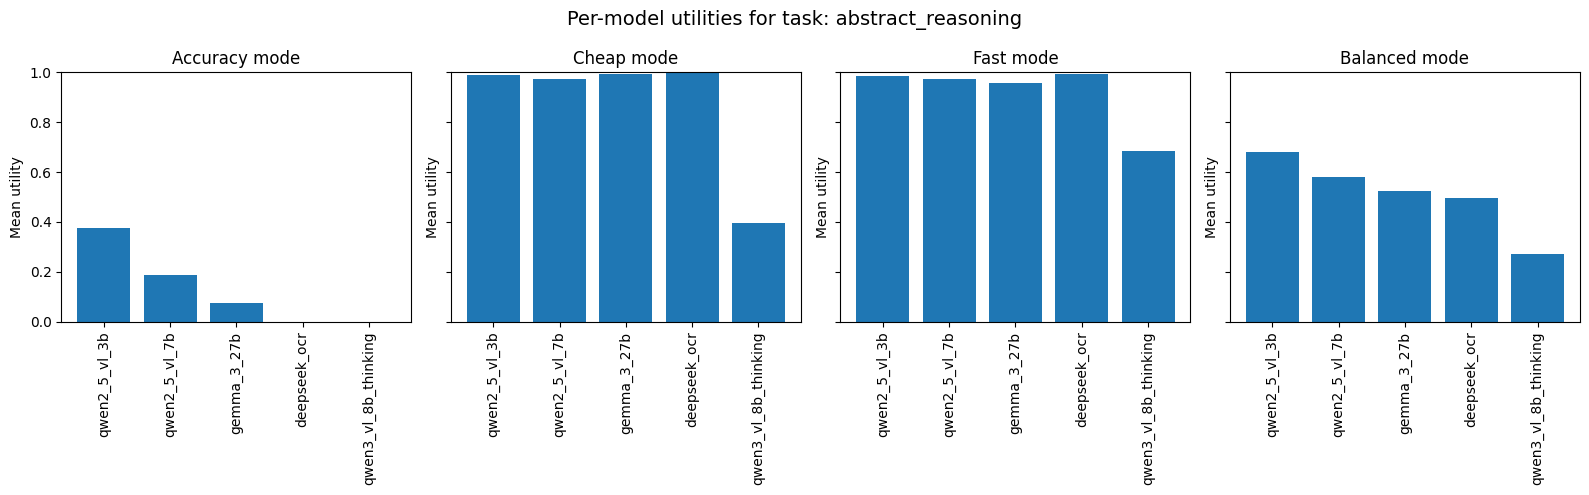

 - chart_captioning


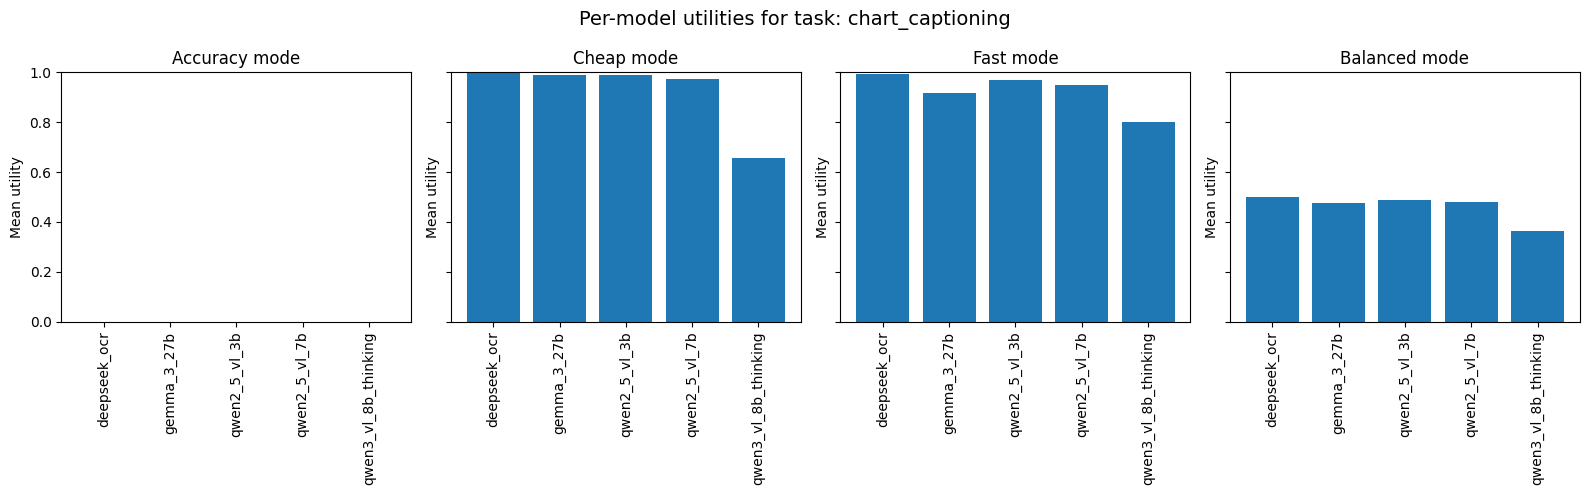

 - chart_reasoning


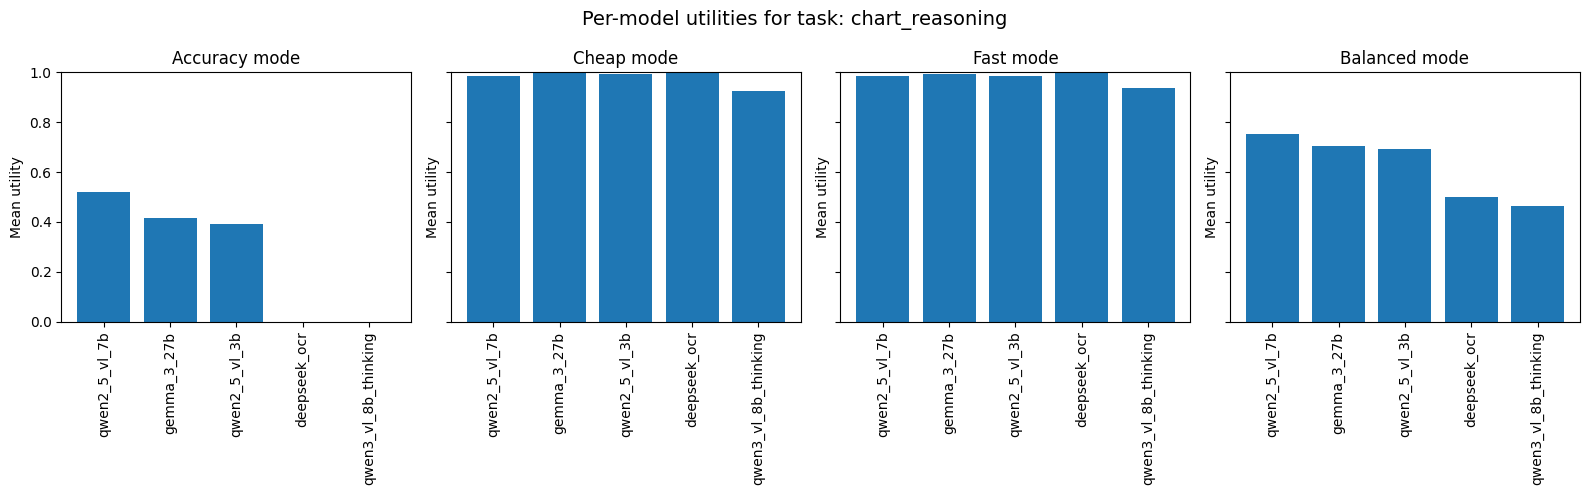

 - code_generation


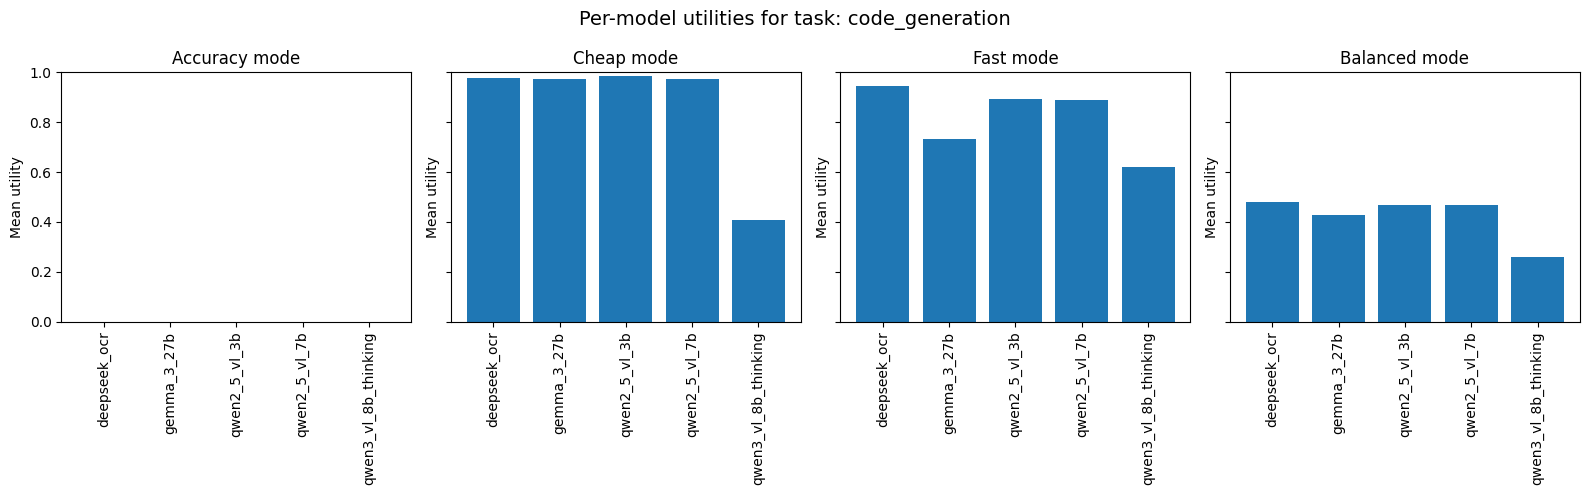

 - counting


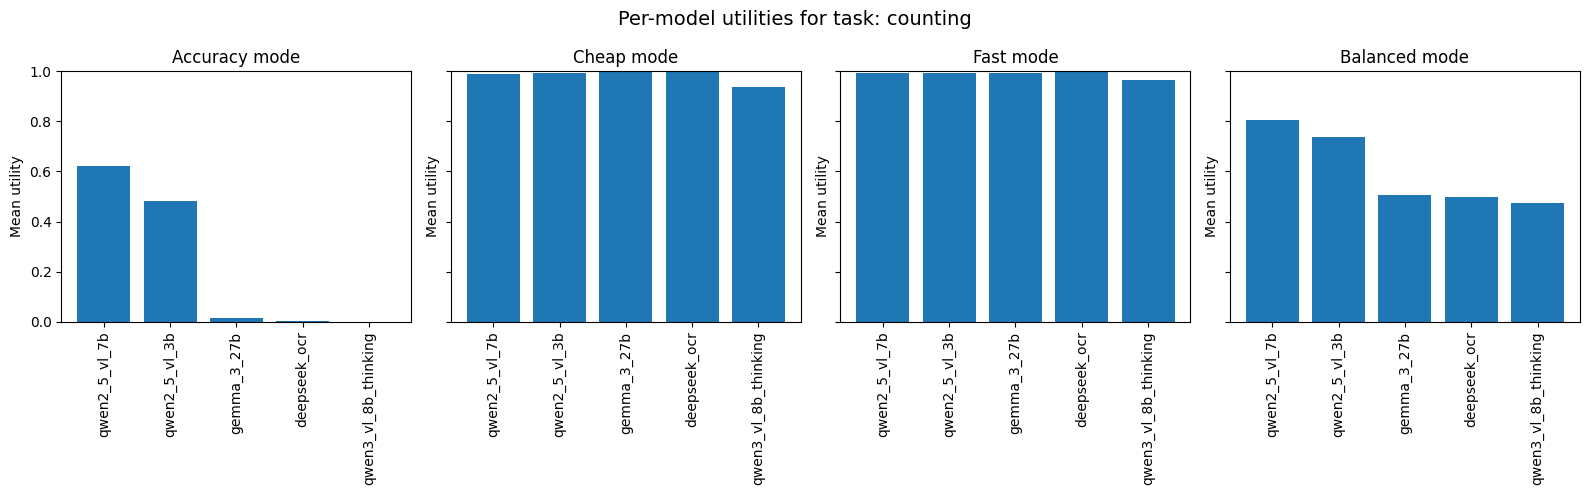

 - dense_captioning


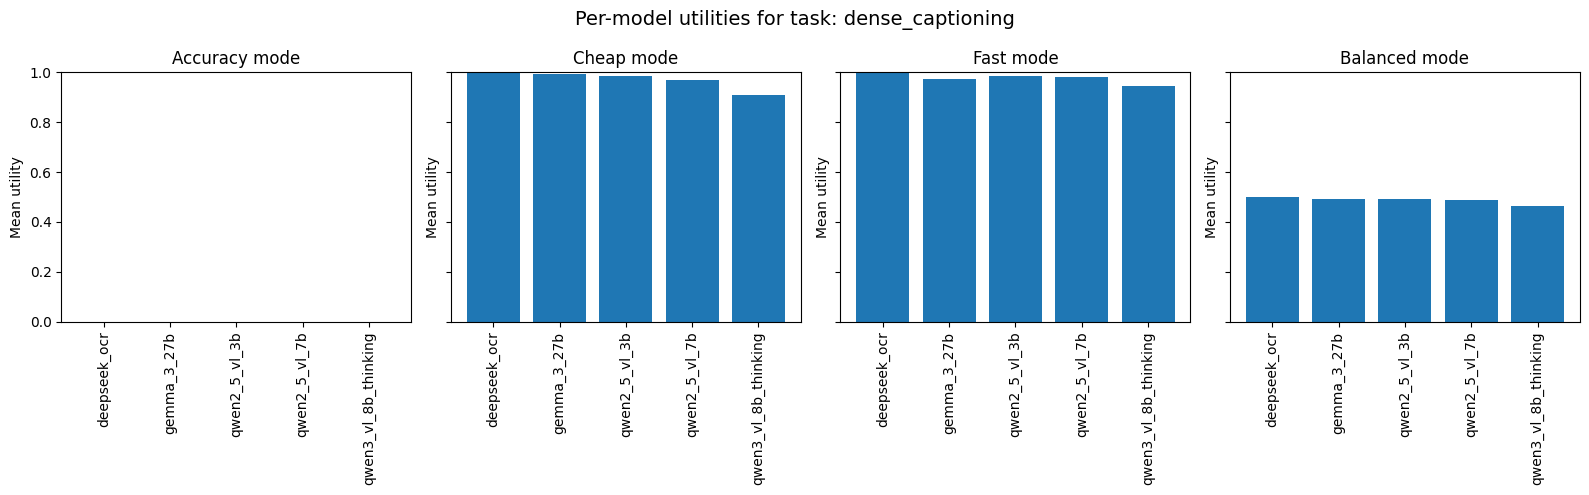

 - diagram_captioning


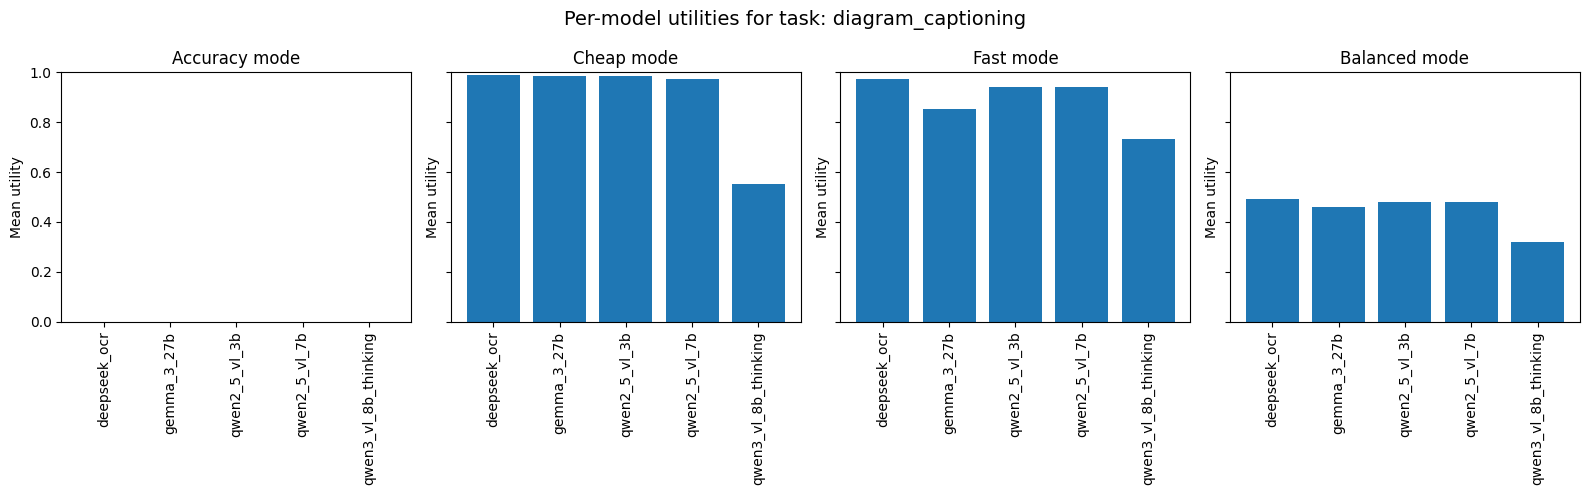

 - diagram_reasoning


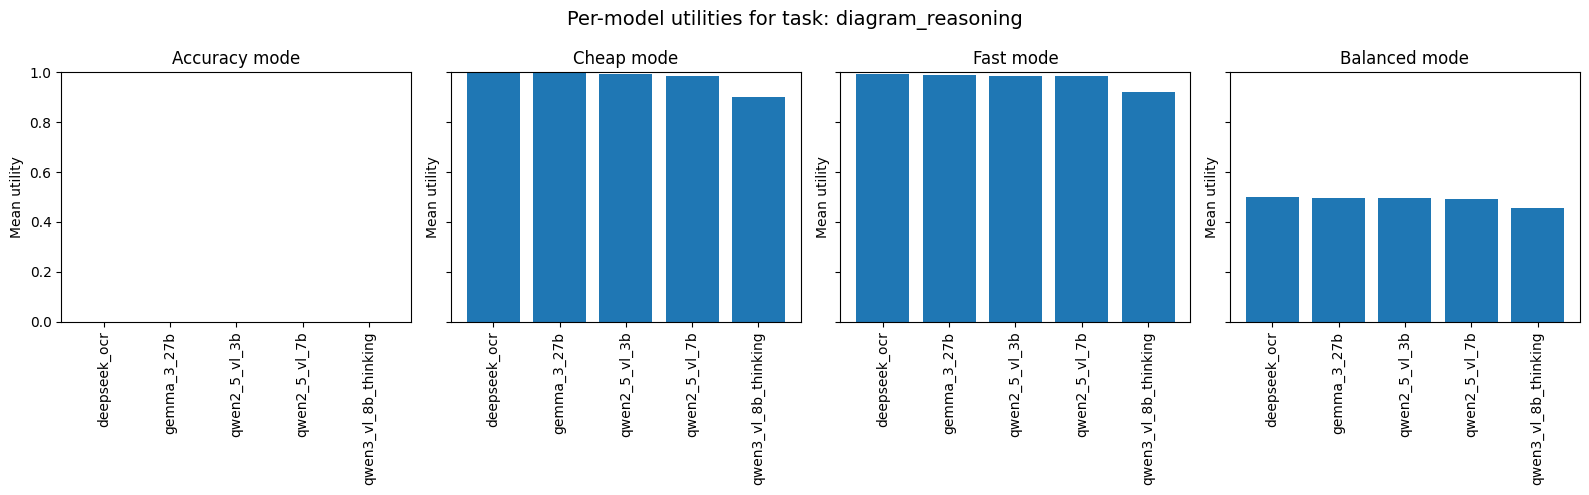

 - difference_detection


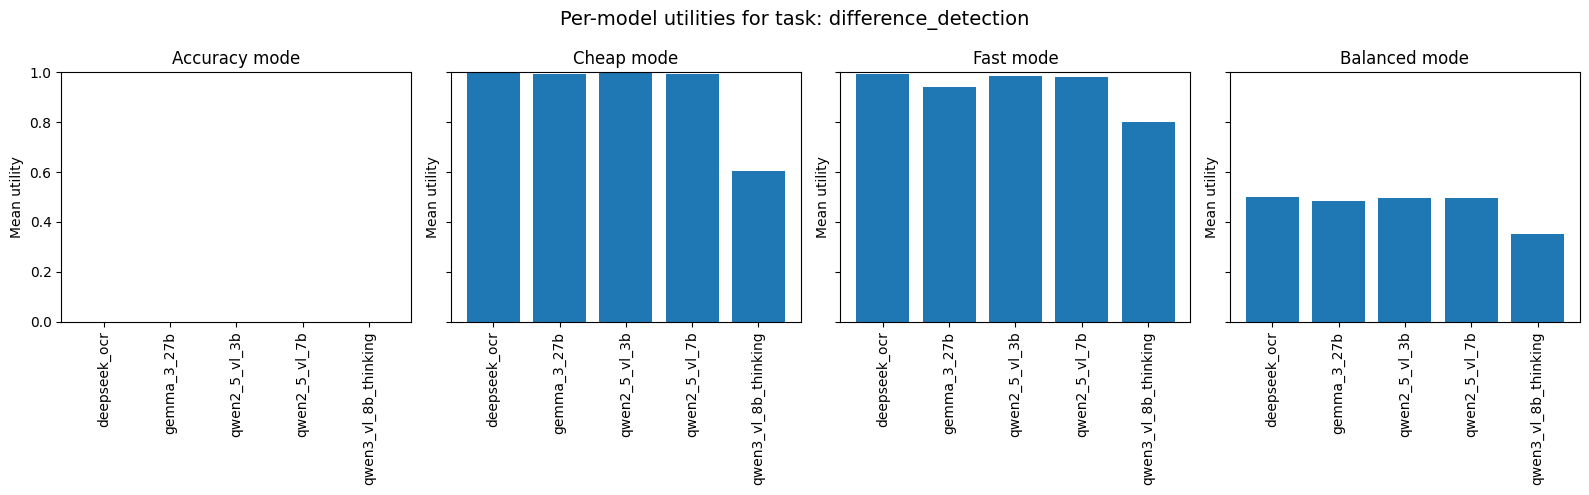

 - document_ocr


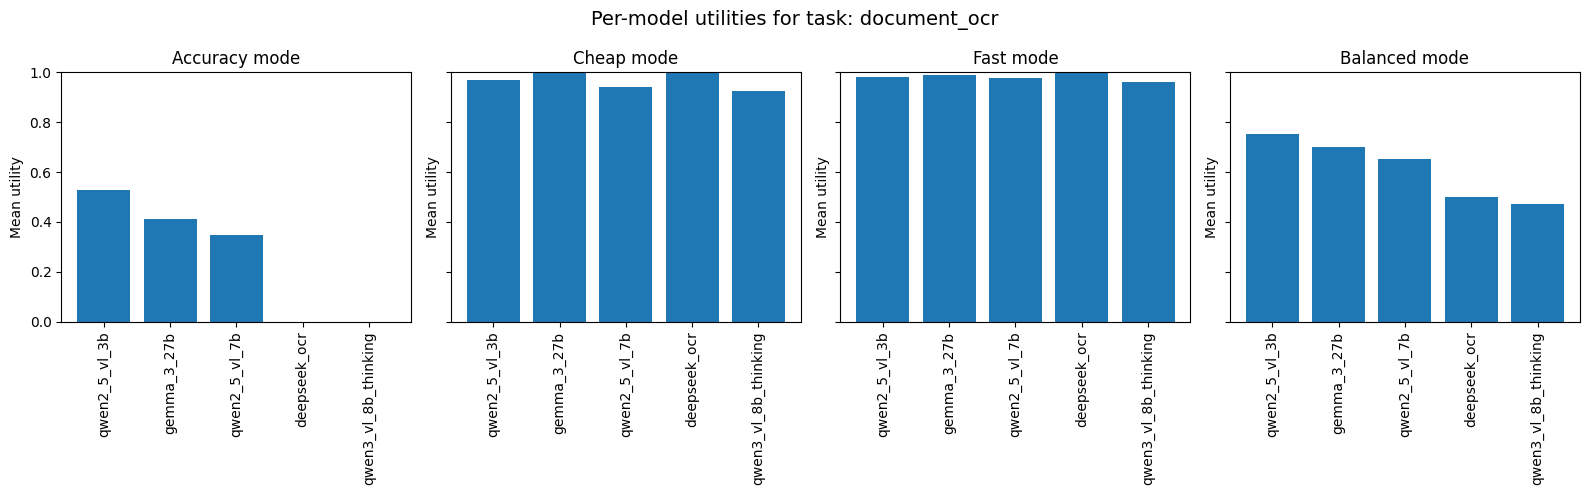

 - general_vqa


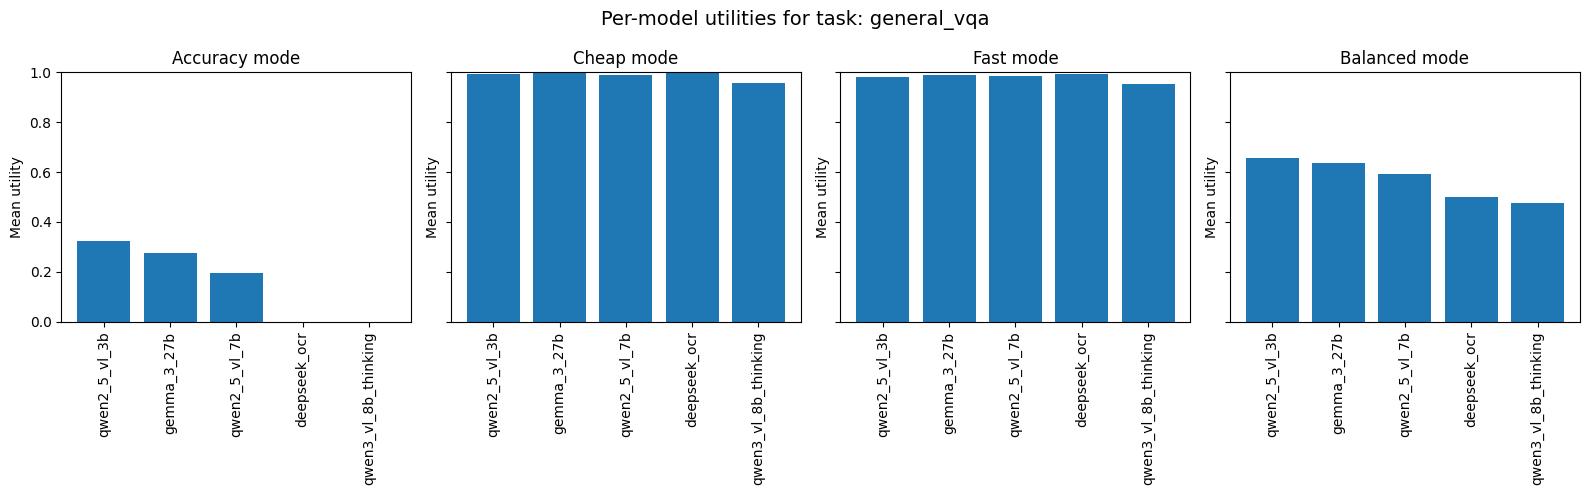

 - geometry_reasoning


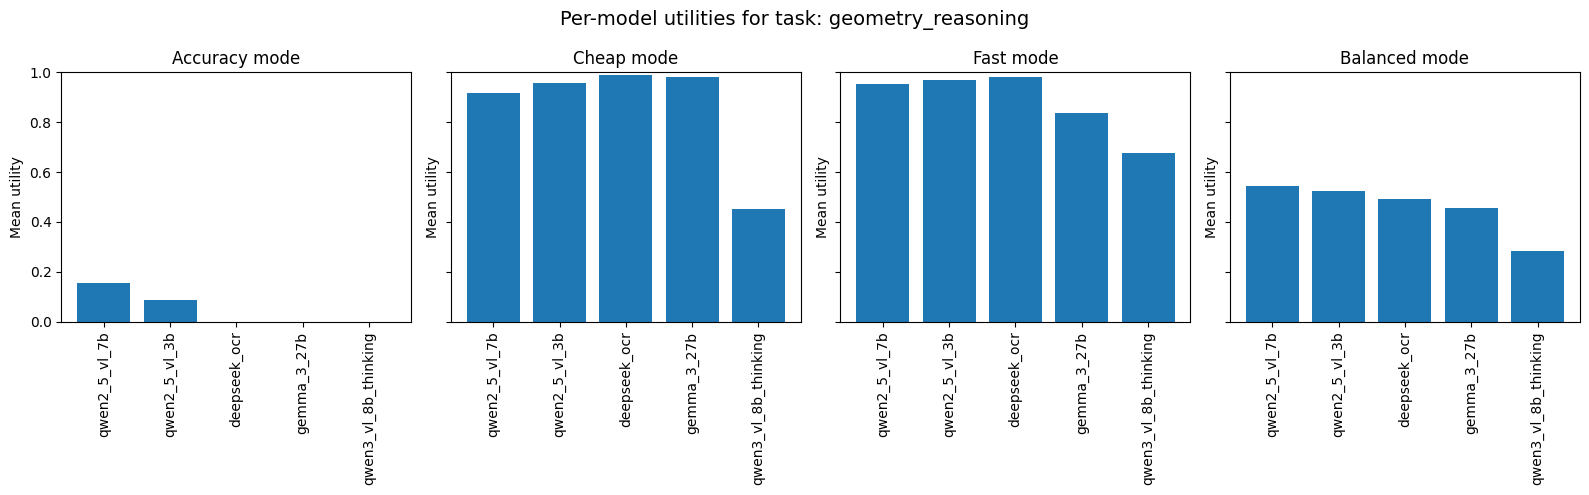

 - handwriting_ocr


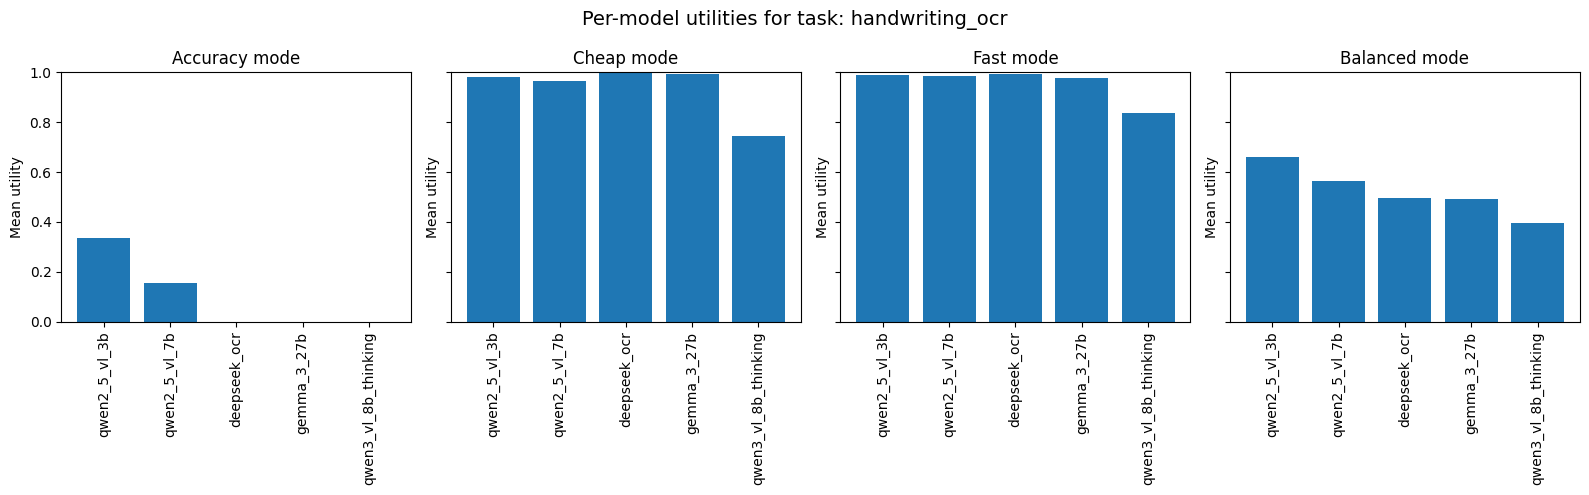

 - icon_reasoning


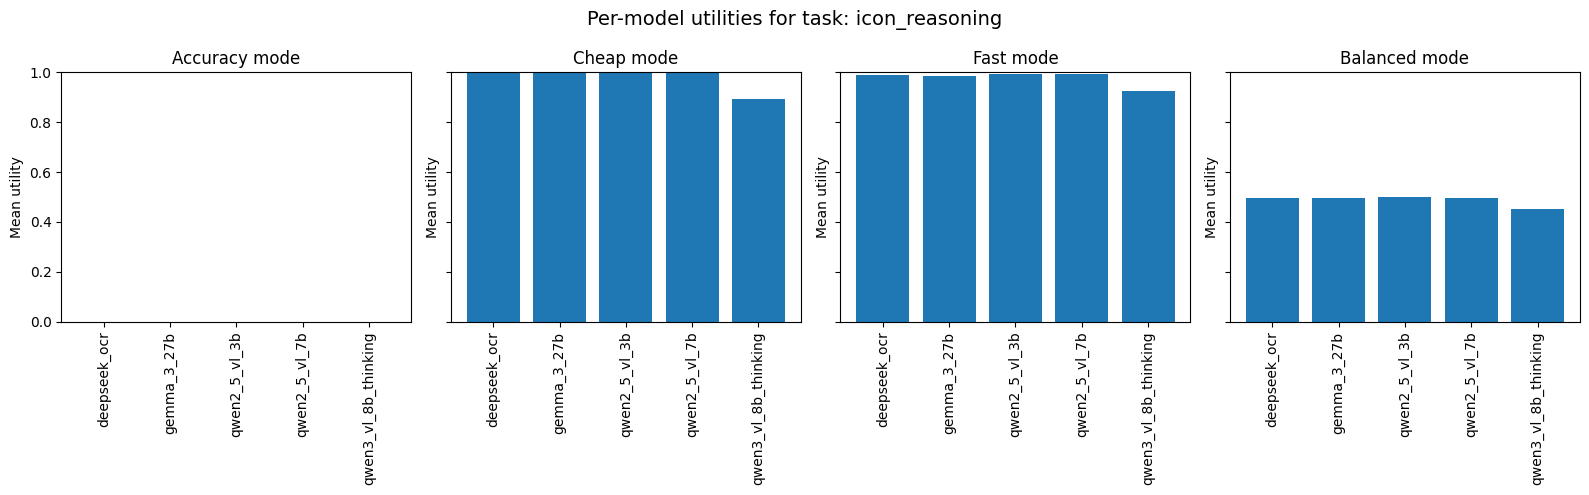

 - image_captioning


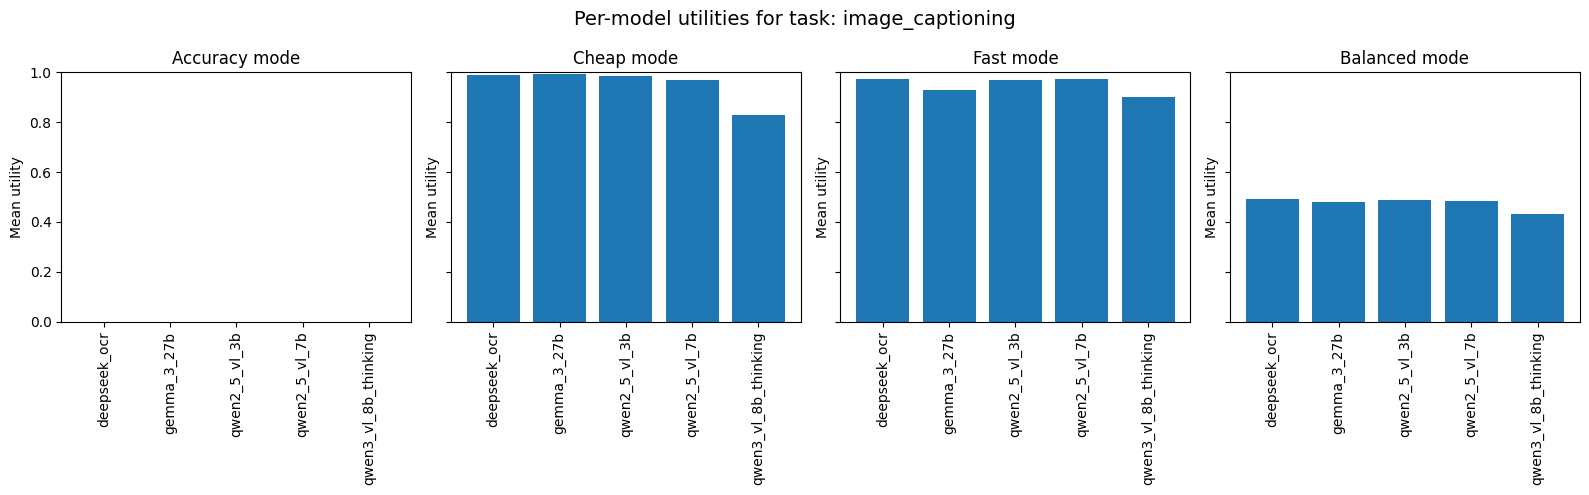

 - knowledge_vqa


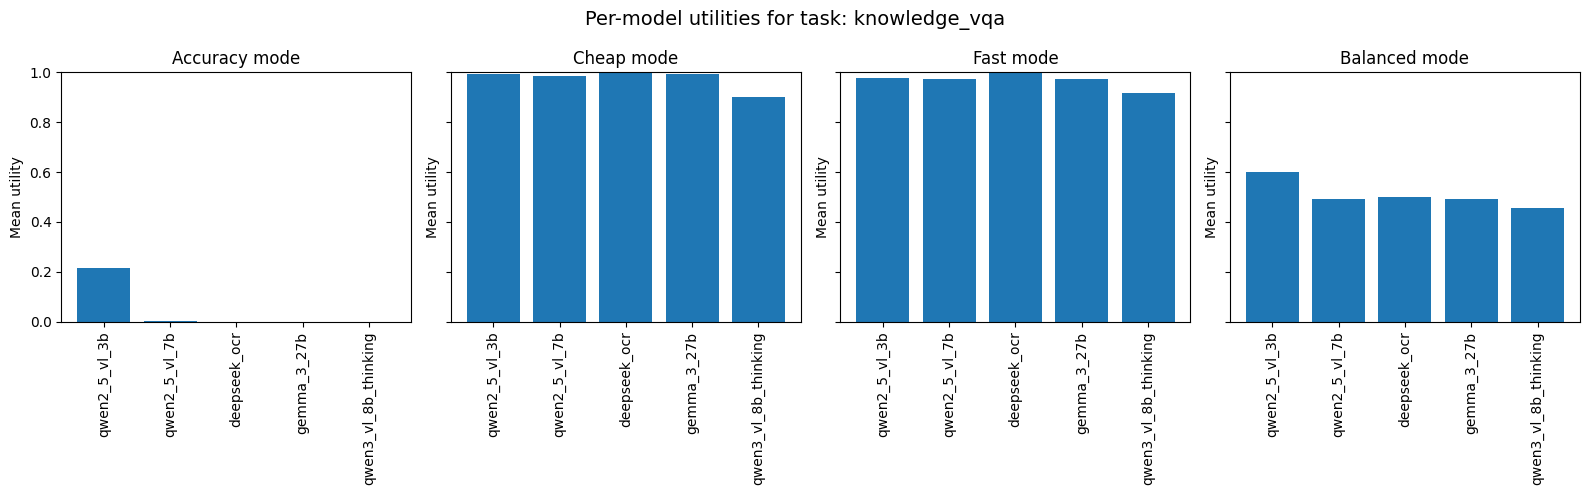

 - map_reasoning


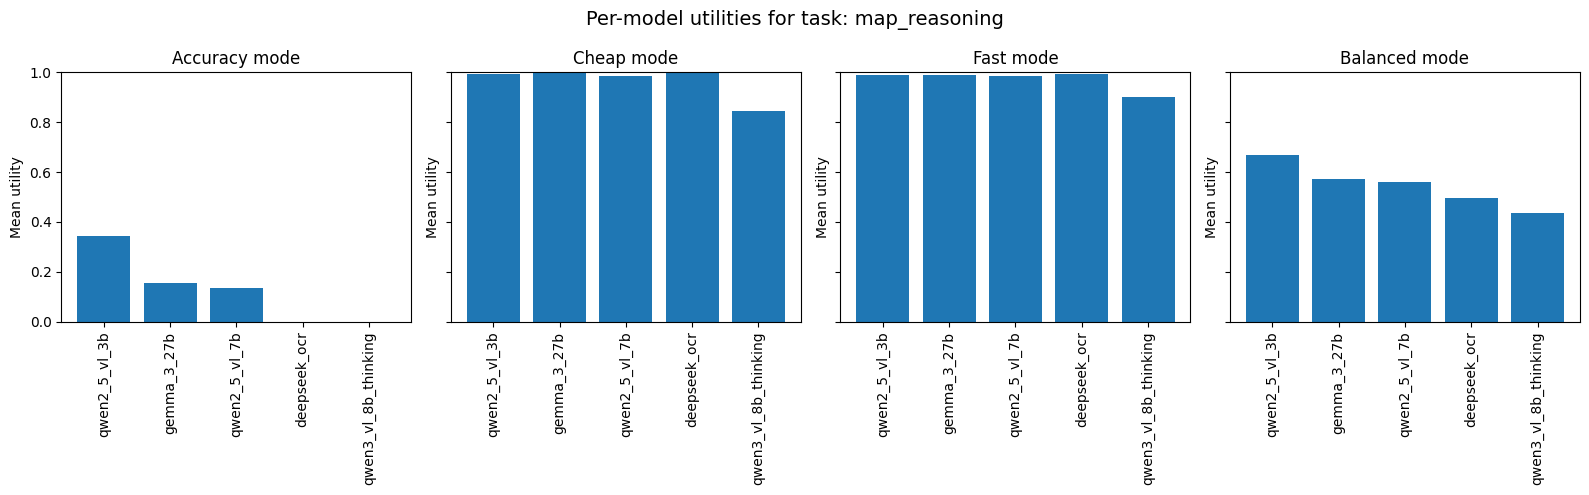

 - medical_report


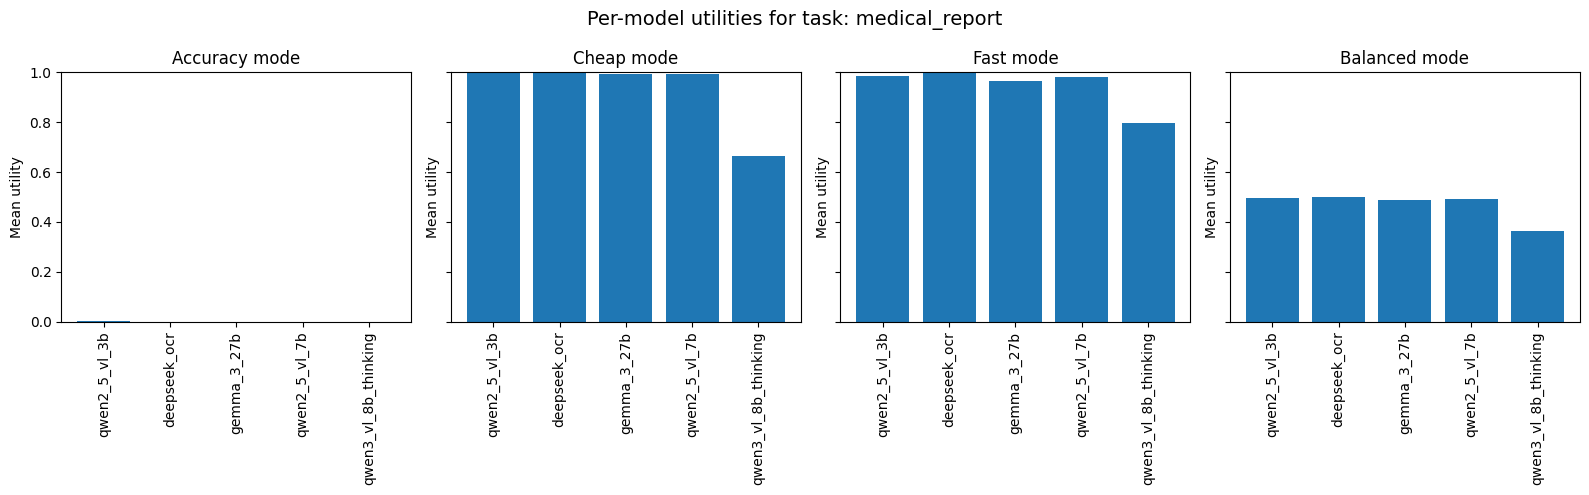

 - medical_vqa


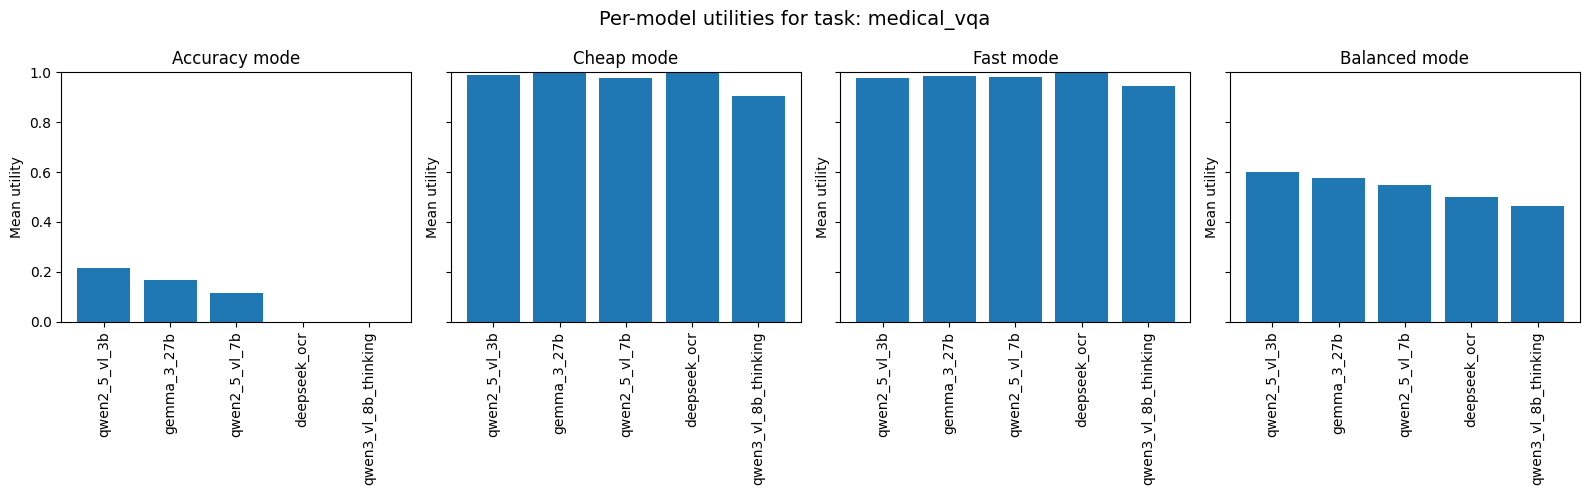

 - meme_classification


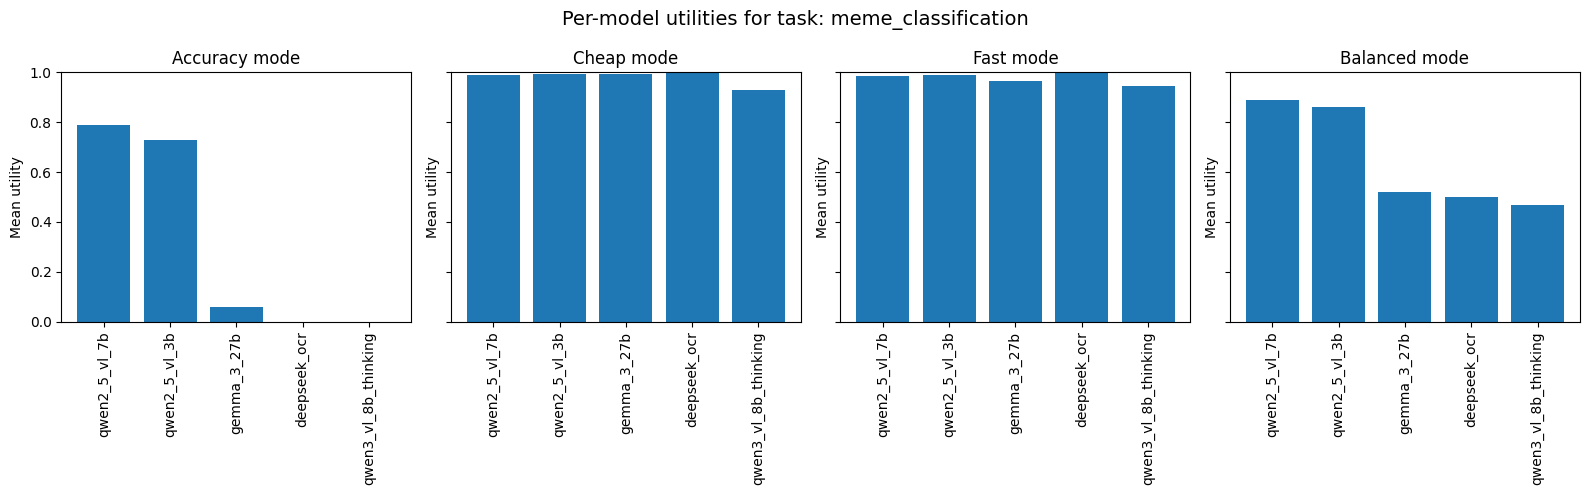

 - rendered_text_ocr


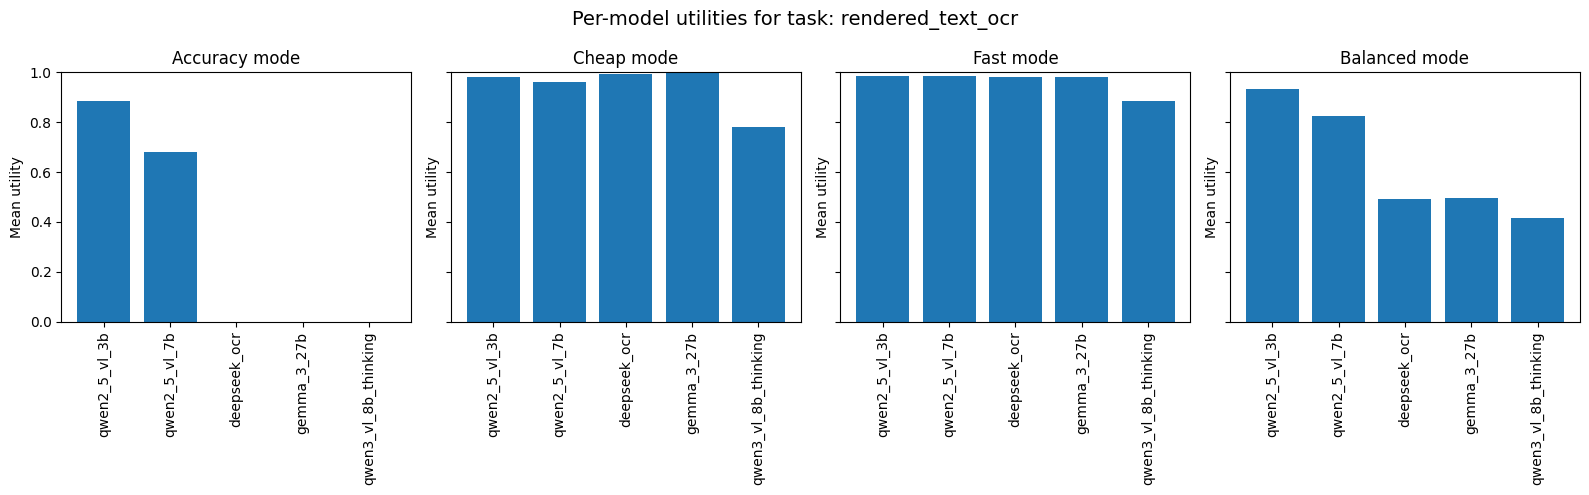

 - scene_text_ocr


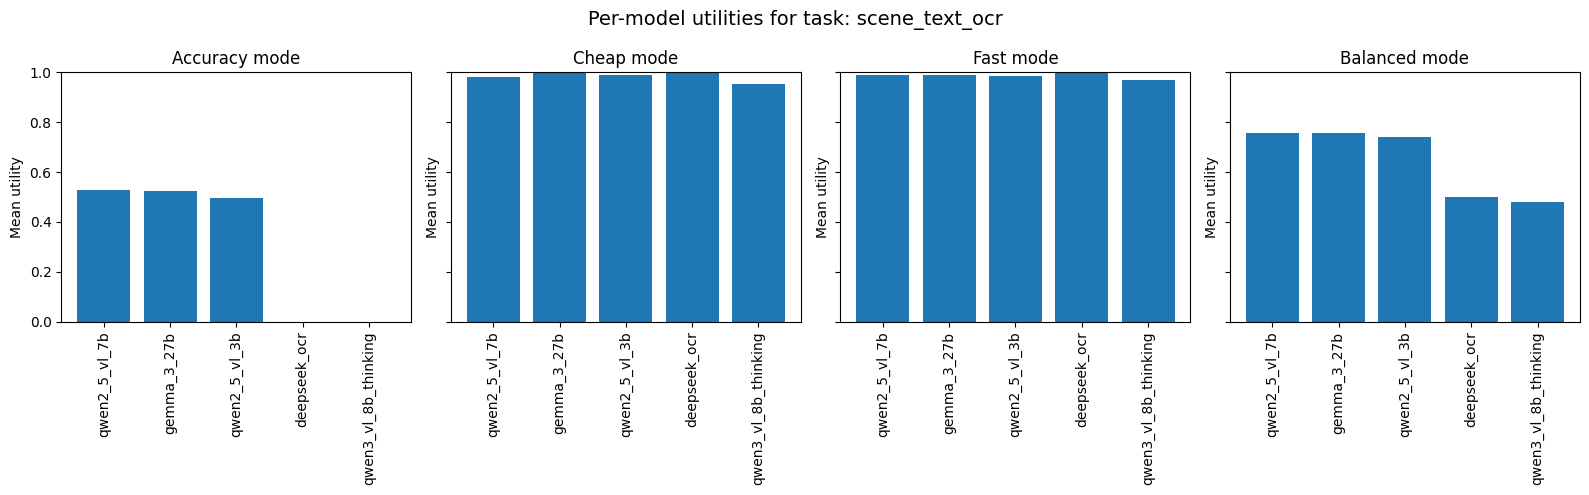

 - science_reasoning


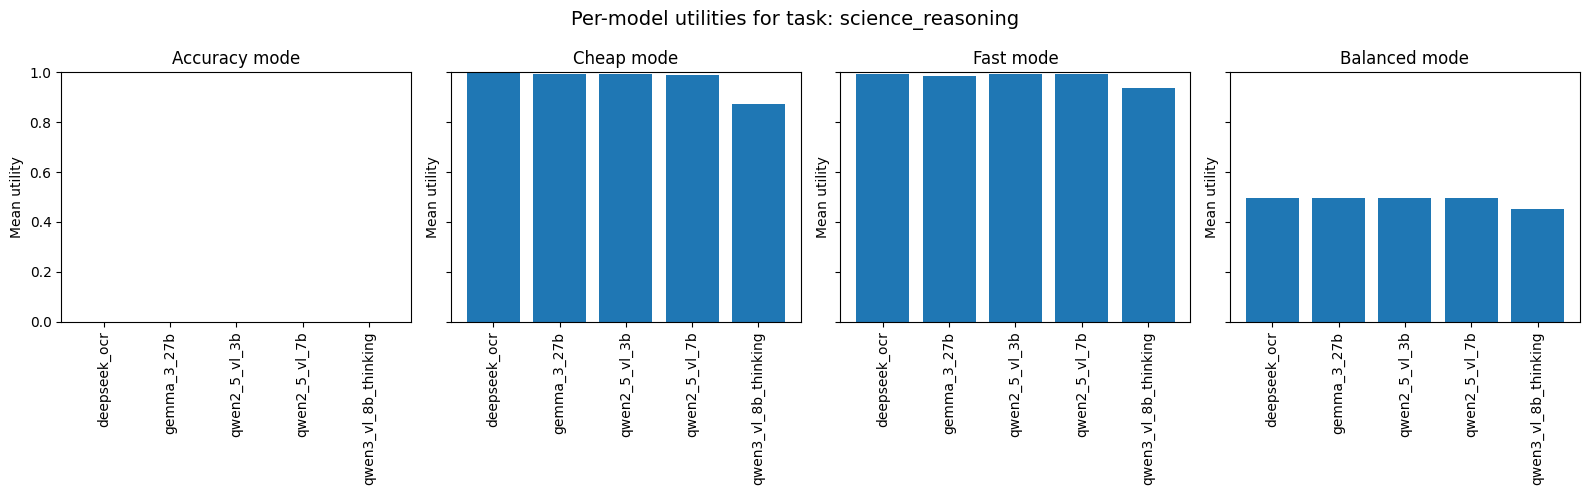

 - spatial_reasoning


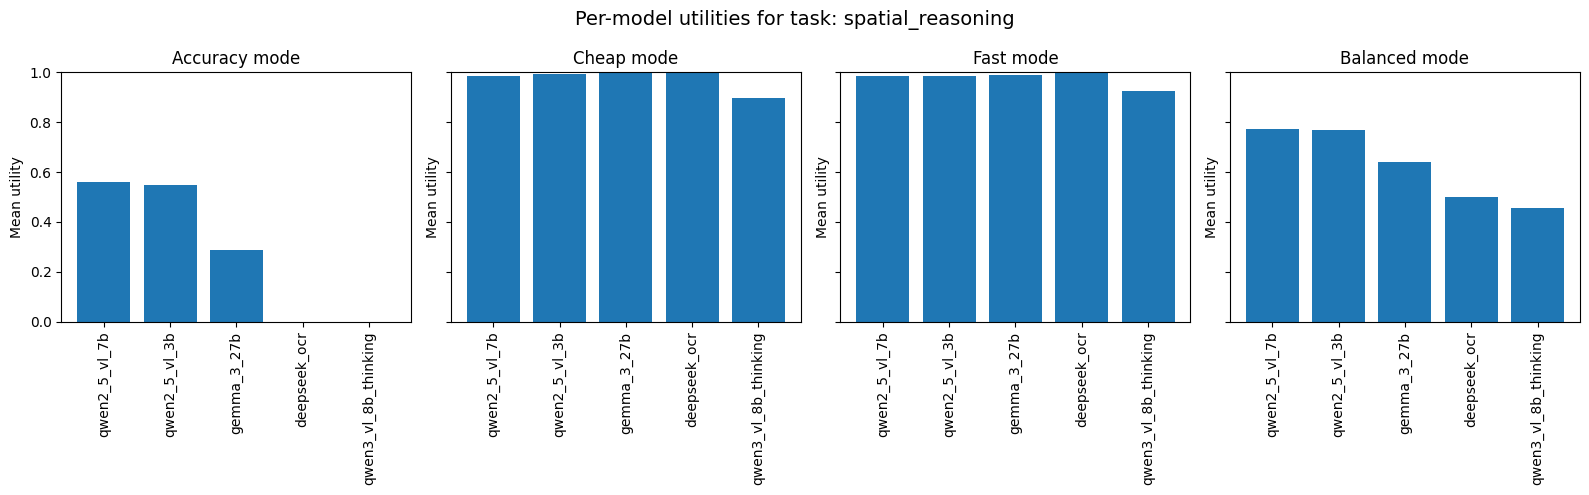

 - table_math


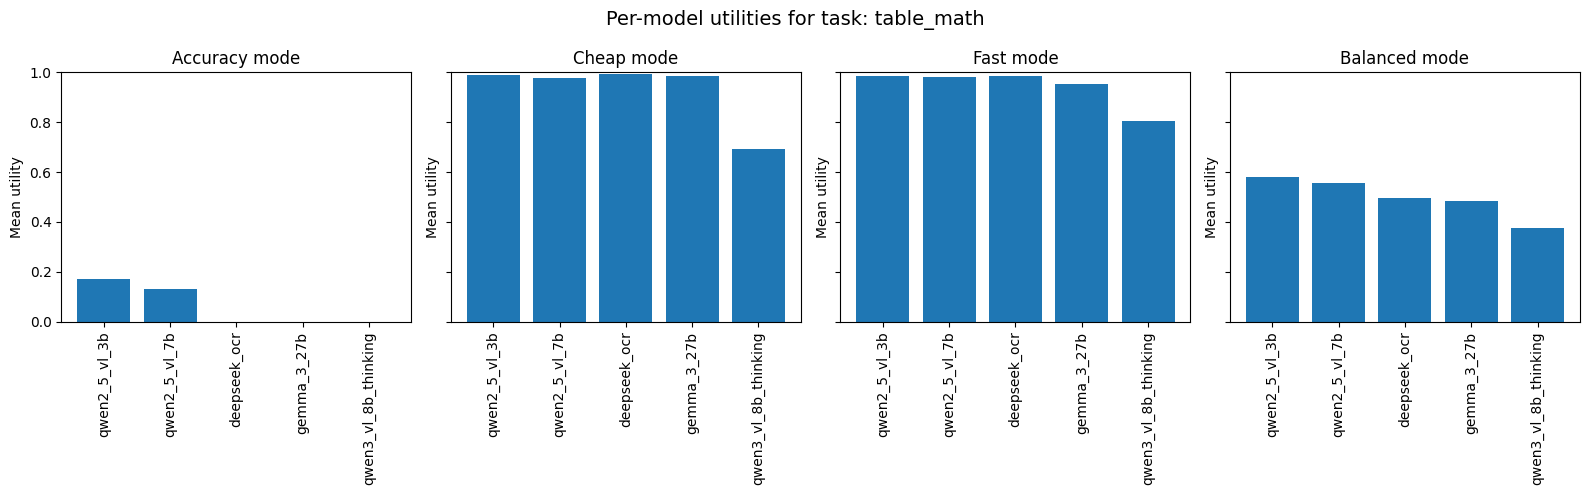

 - table_reasoning


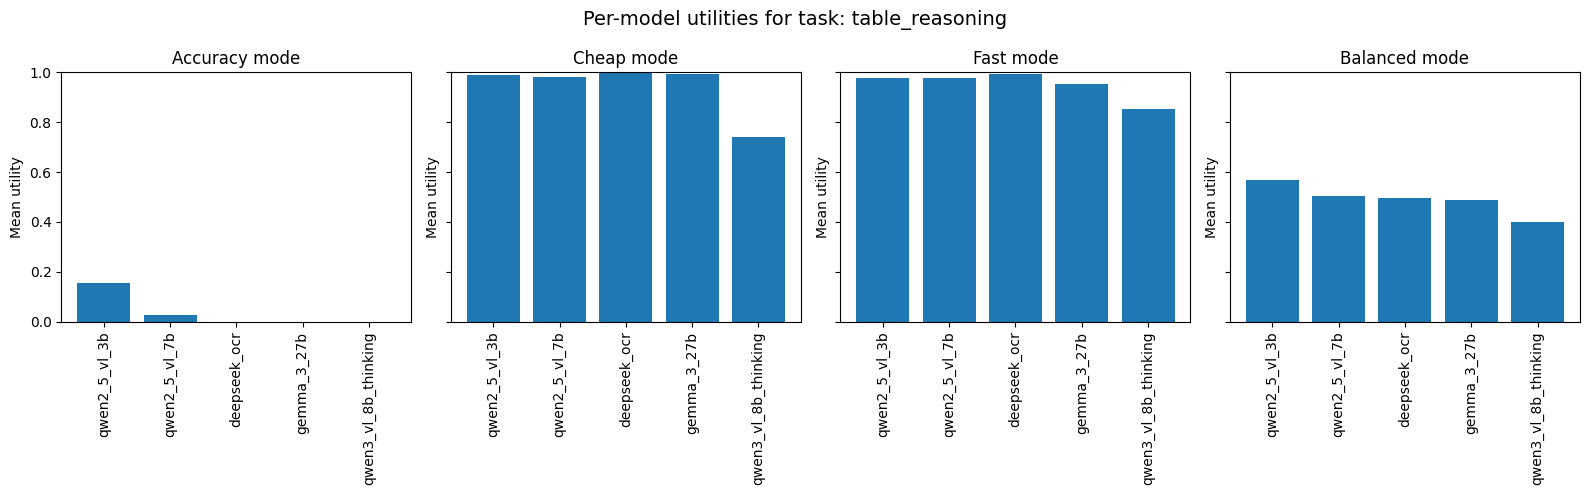

 - textbook_qa


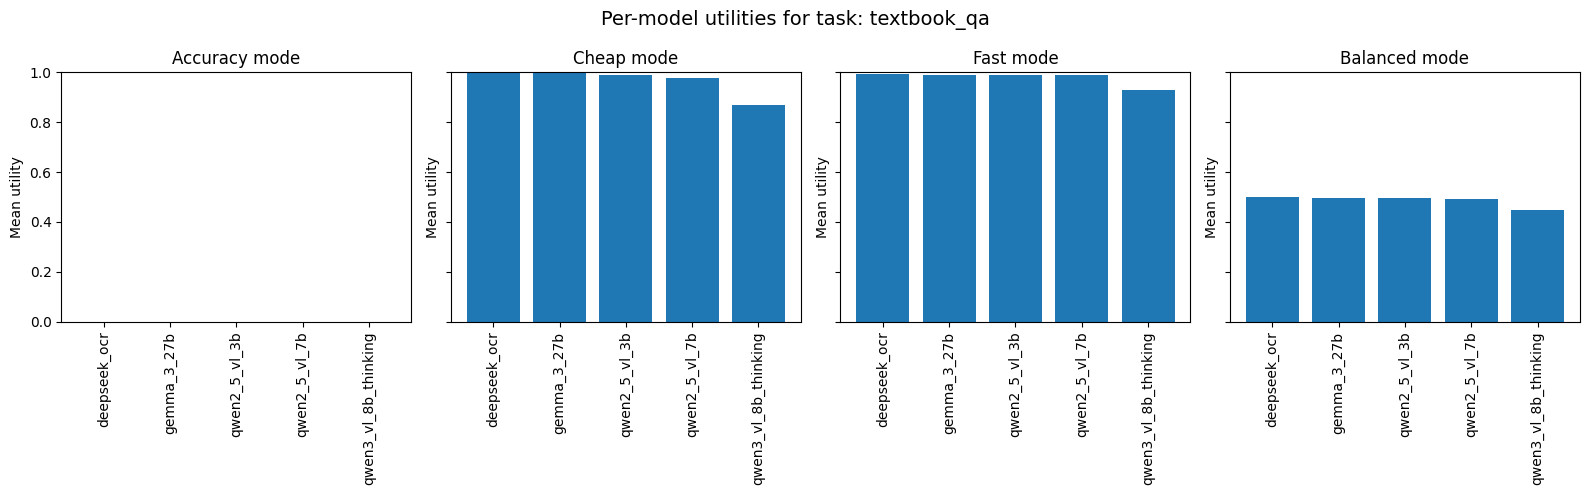

 - ui_captioning


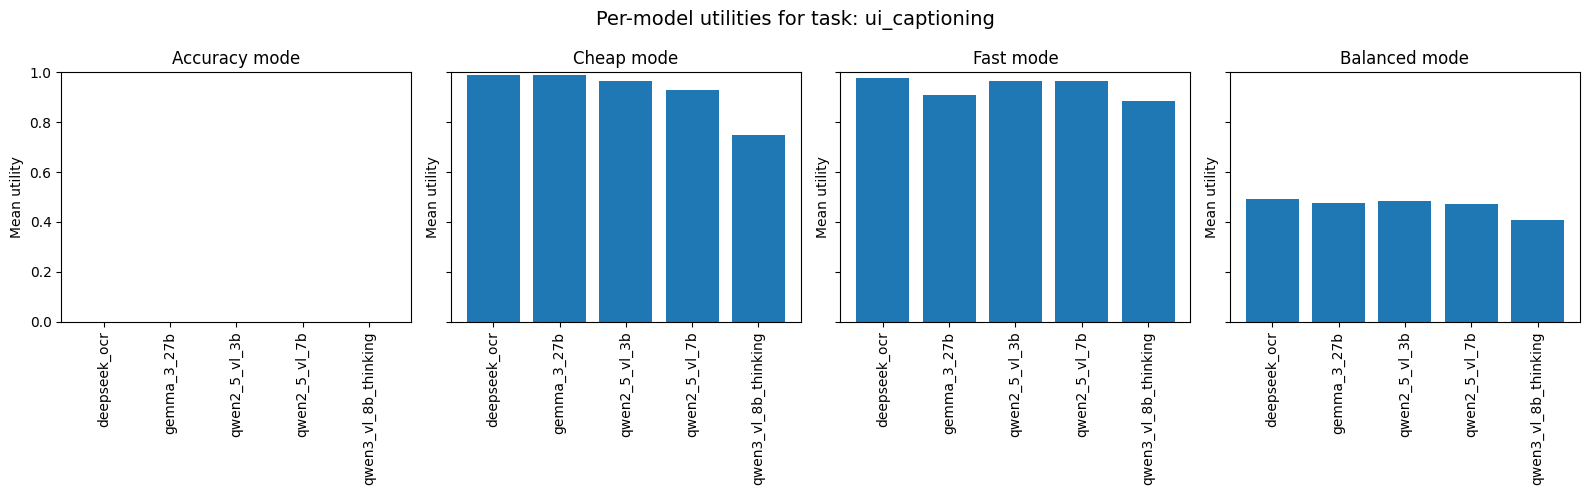

 - visual_mrc


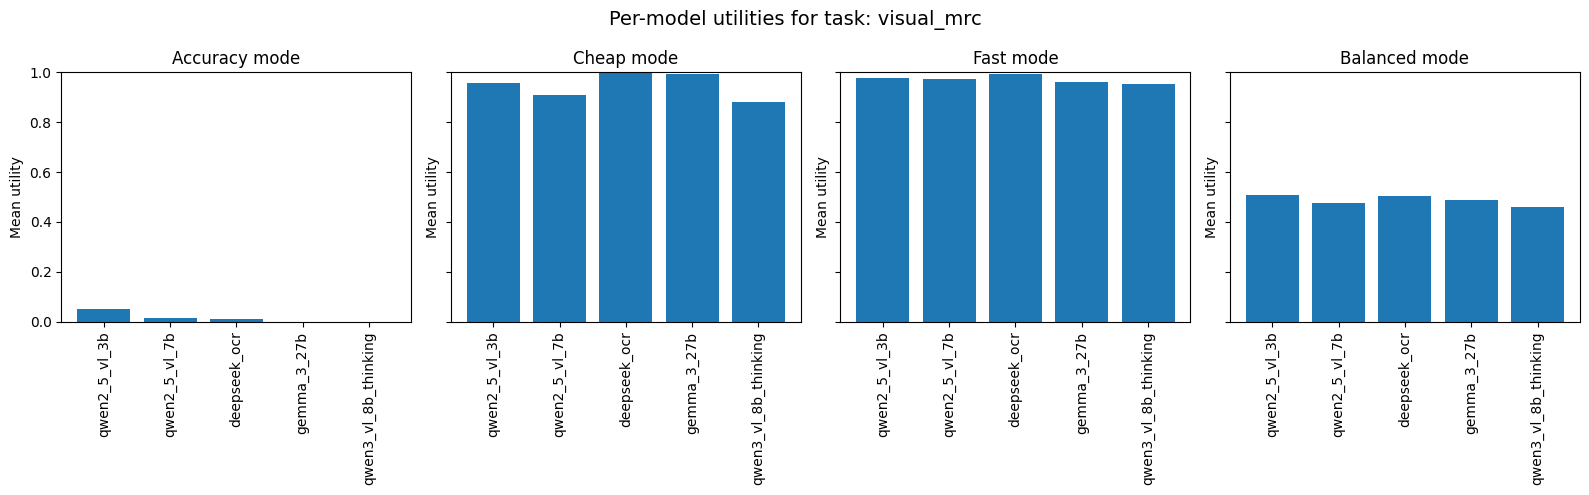

 - web_understanding


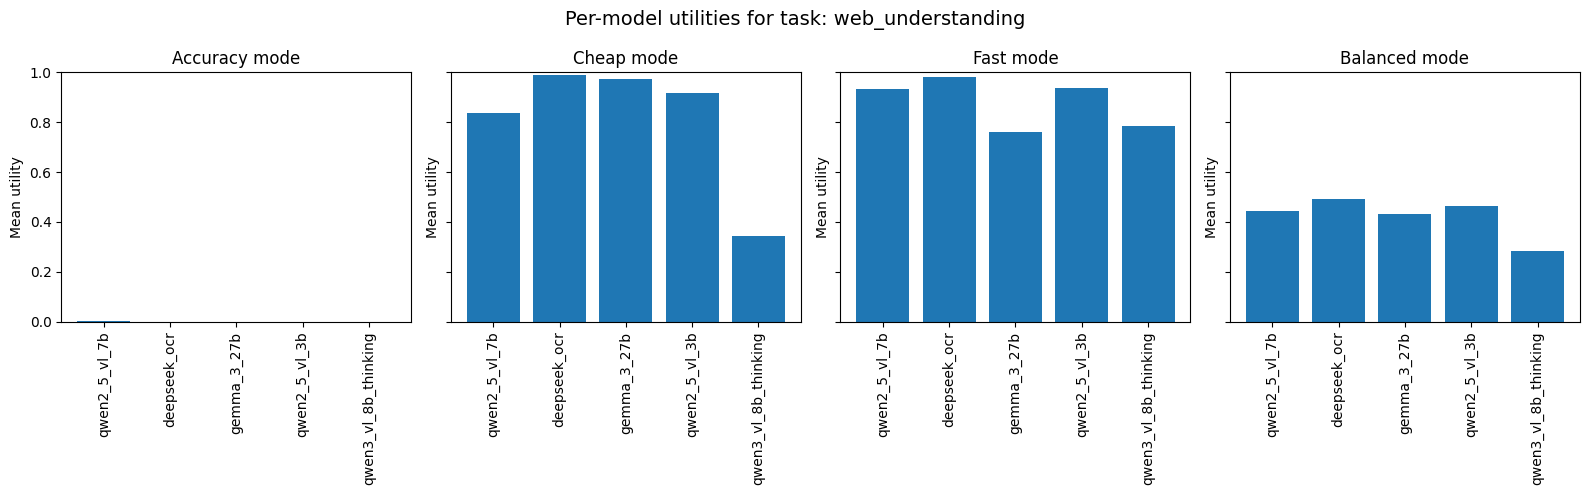

In [17]:
for t in all_tasks:
    print(" -", t)

# print("\nUse: plot_task_mode_utilities('<task_name>', top_k=5)")
    plot_task_mode_utilities(t, top_k=5)  